In [1]:
!git clone https://github.com/dramirezbe/DataBase-RF-FM-88MHz-108MHz-Bogota-Funza.git

fatal: destination path 'DataBase-RF-FM-88MHz-108MHz-Bogota-Funza' already exists and is not an empty directory.


In [25]:
import pandas as pd
import glob
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import ast

csv_files = glob.glob("DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node*.csv")
node_data = {}

# Load all CSV files into memory with a progress bar, excluding Node8
for csv_file in tqdm(csv_files, desc="Loading CSVs"):
    # Skip any file that contains "Node8" in its name
    if "Node8" in csv_file:
        continue
        
    node_name = csv_file.replace('.csv', '')
    node_data[node_name] = pd.read_csv(csv_file)

Loading CSVs: 100%|██████████| 10/10 [00:09<00:00,  1.04it/s]


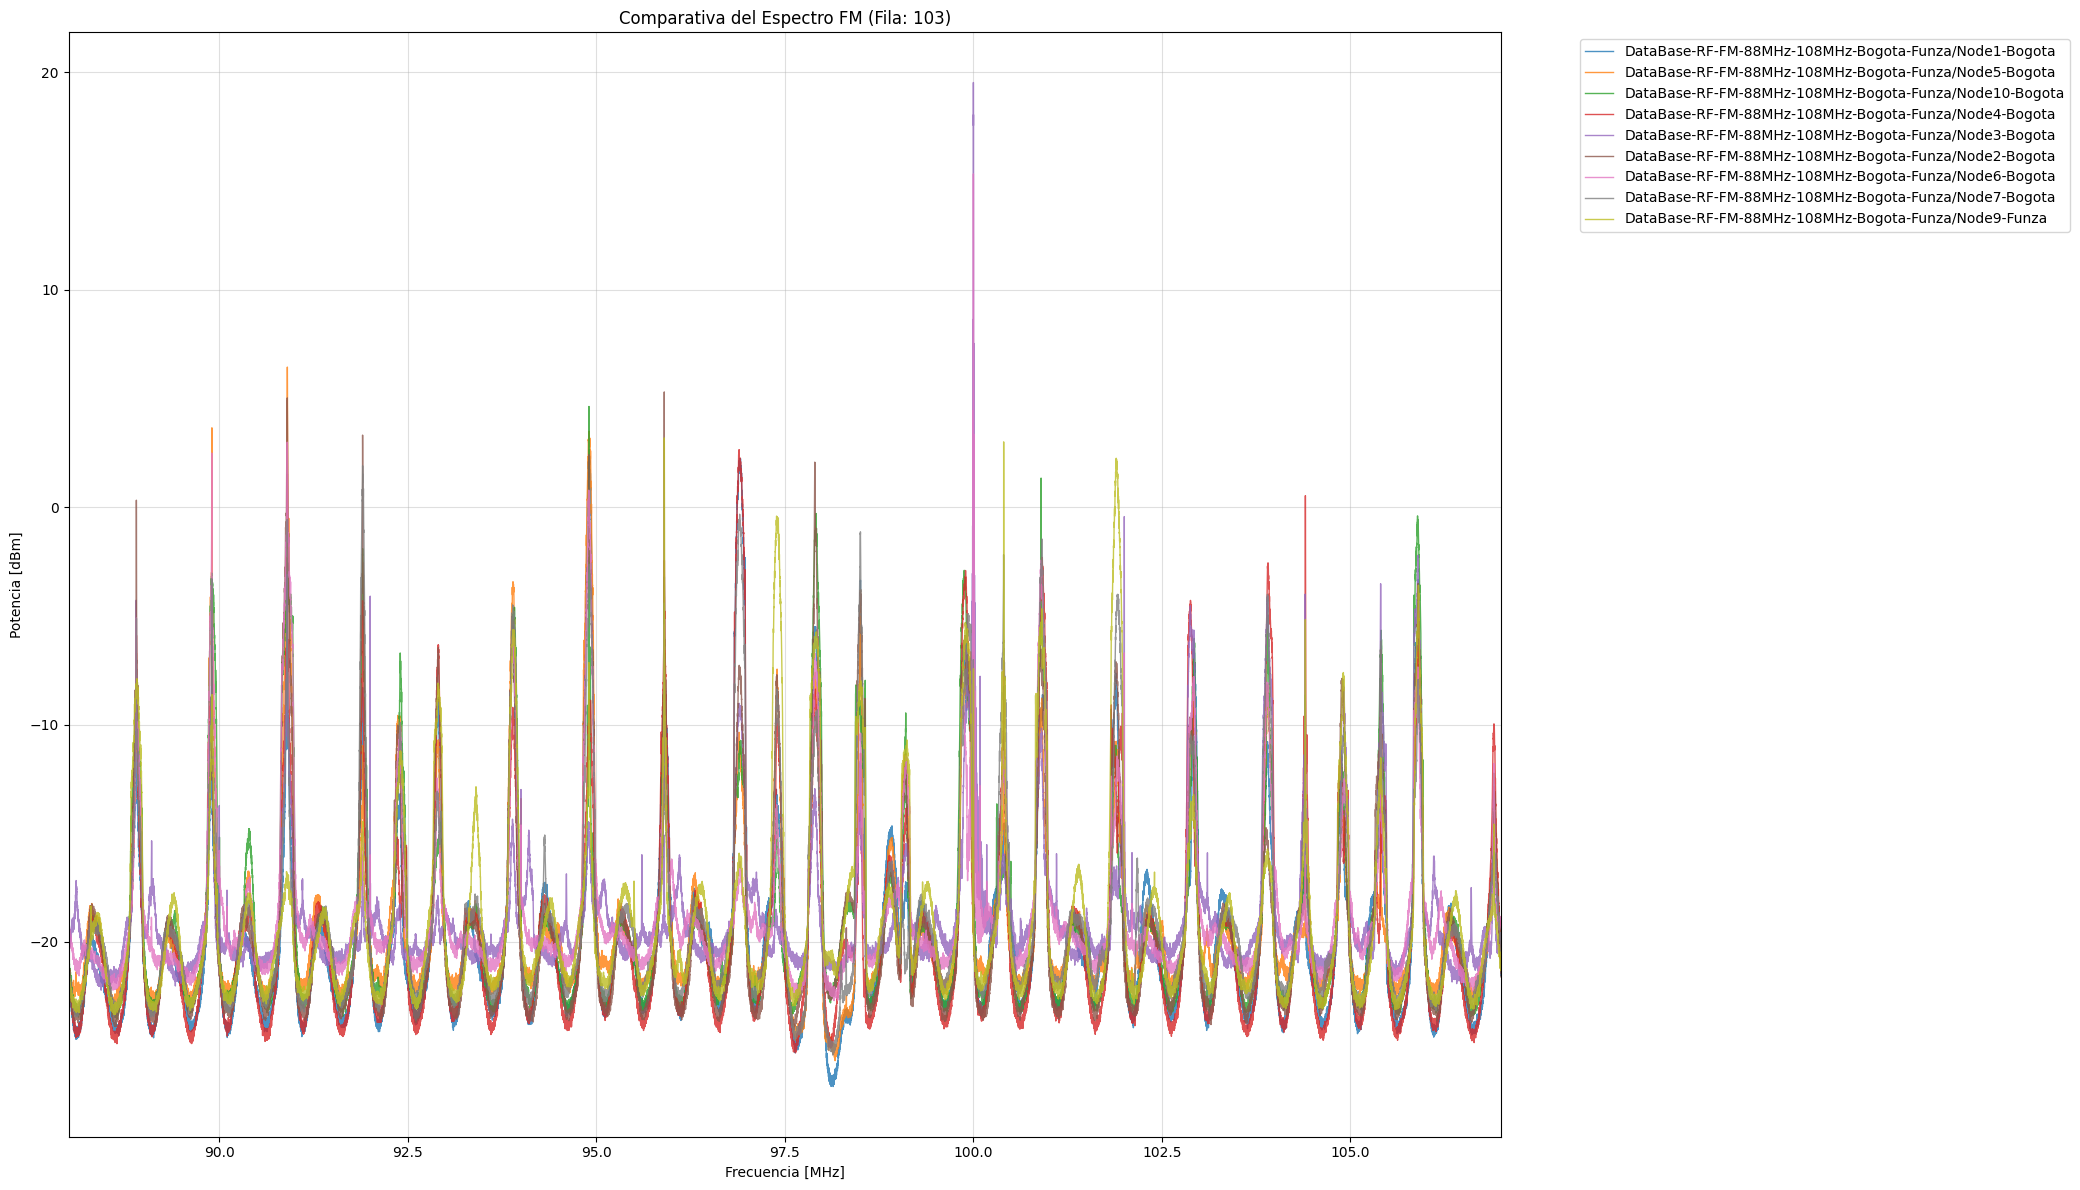

In [34]:
ROW_PLOT = 103  # Change this number to plot another row [0, 22]

plt.figure(figsize=(21, 12))

for node_name, df in node_data.items():
    # Extract the list from the selected row
    pxx = ast.literal_eval(df['pxx'].iloc[ROW_PLOT])
    frequencies = np.linspace(88, 108, len(pxx))
    
    plt.plot(frequencies, pxx, label=node_name, linewidth=1, alpha=0.8)

plt.title(f"FM Spectrum Comparison (Row: {ROW_PLOT})")
plt.xlabel("Frequency [MHz]")
plt.ylabel("Power [dBm]")
plt.xlim(min(frequencies),max(frequencies)-1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

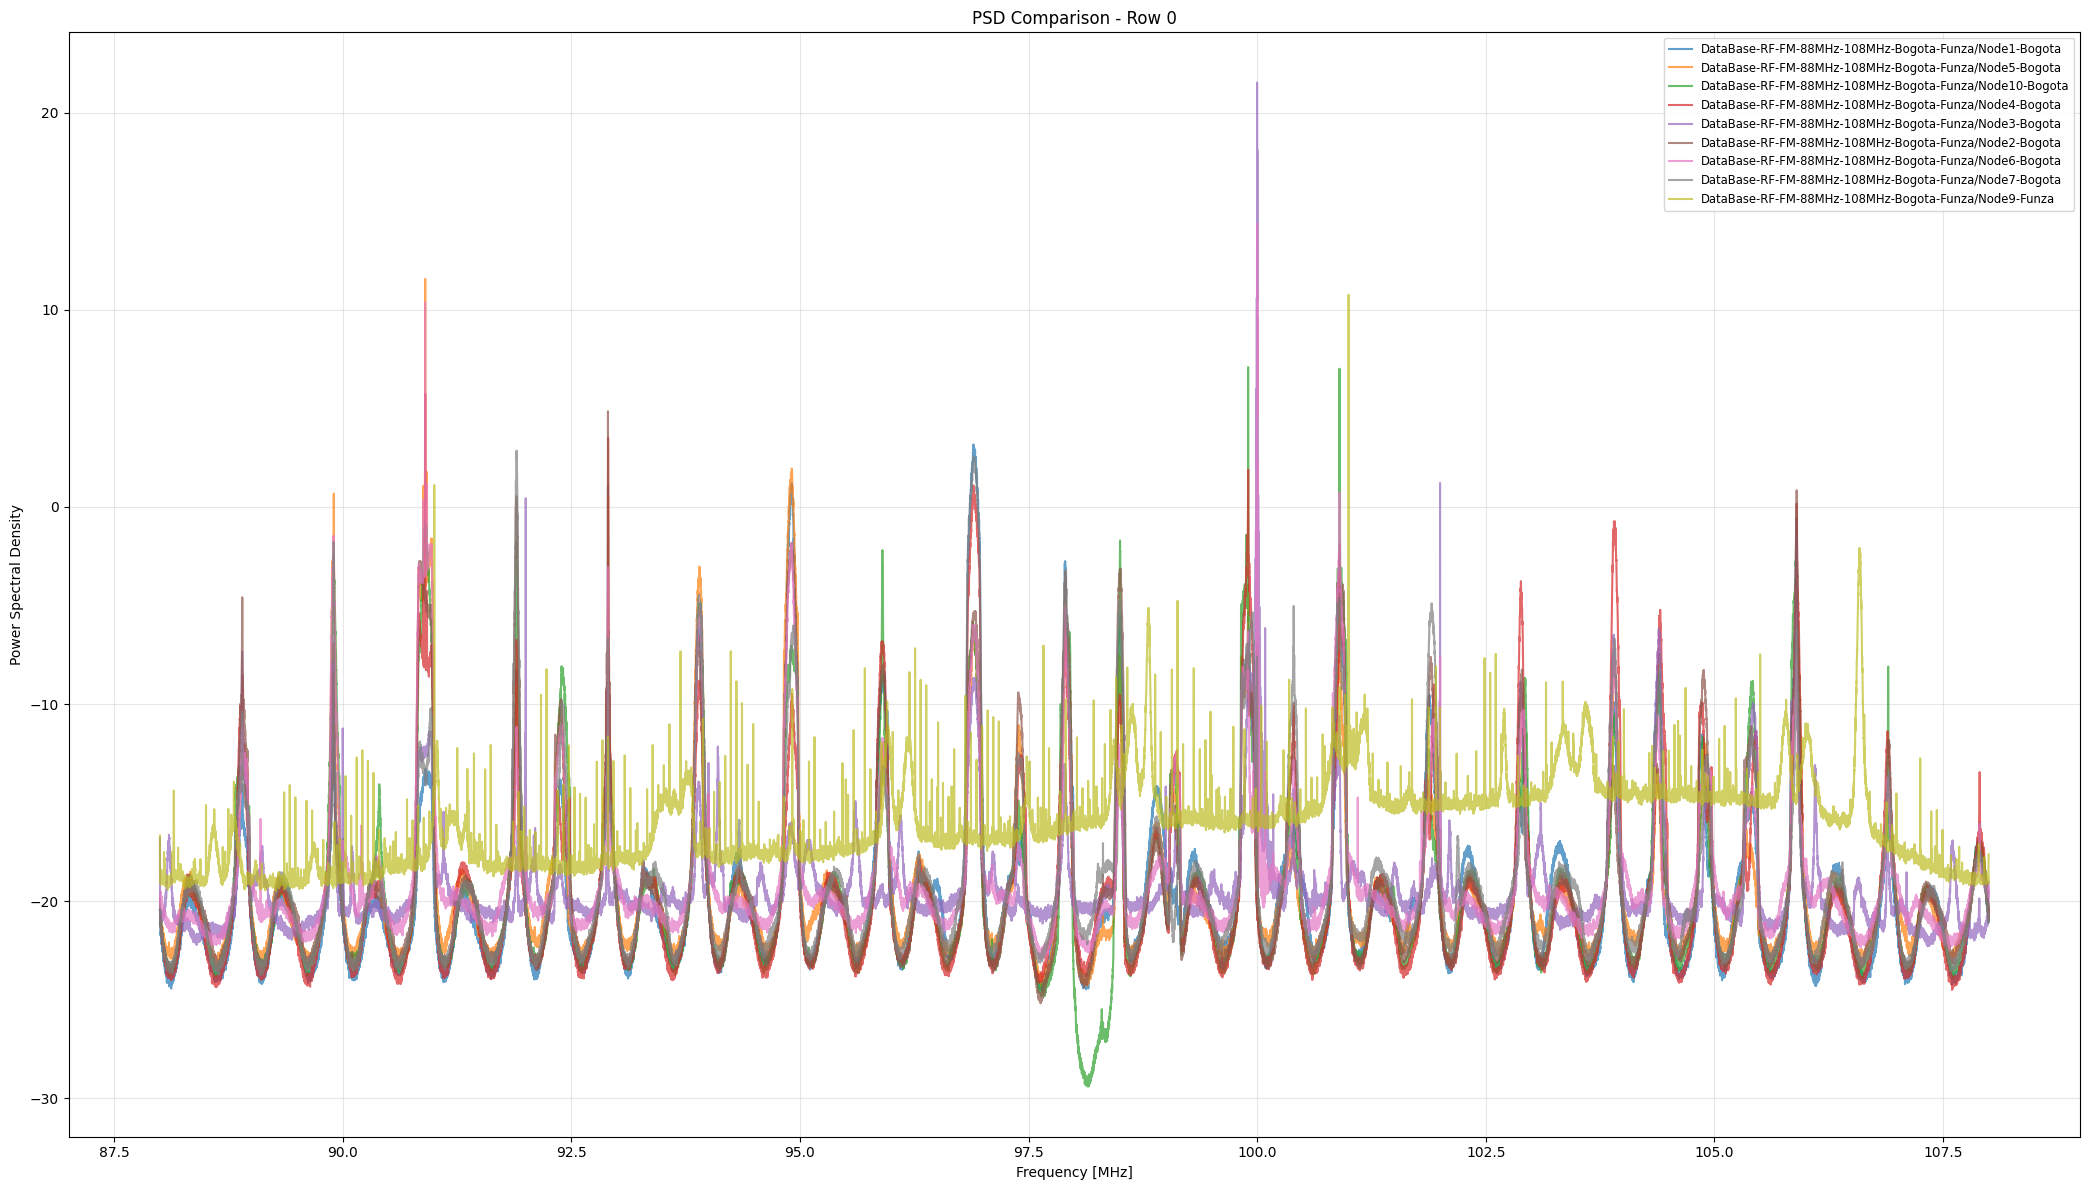

In [37]:
import ast
import numpy as np
import matplotlib.pyplot as plt

ROW_PLOT = 0  # Change this to plot a different row [0, 105]

# Container: {node_name: {row_index: pxx_array}}
pxx_indexed = {}  

plt.figure(figsize=(21, 12))

for node_name, df in node_data.items():
    # Initialize nested dict for this node if needed
    if node_name not in pxx_indexed:
        pxx_indexed[node_name] = {}
    
    # Extract and parse the pxx list from the specified row
    pxx_raw = df['pxx'].iloc[ROW_PLOT]
    pxx = np.array(ast.literal_eval(pxx_raw))  # Convert string → list → numpy array
    
    # Store in indexed structure
    pxx_indexed[node_name][ROW_PLOT] = pxx
    
    # Compute corresponding frequency axis (88–108 MHz band)
    frequencies = np.linspace(88, 108, len(pxx))
    
    # Plot each node data
    plt.plot(frequencies, pxx, label=node_name, alpha=0.7)

plt.xlabel("Frequency [MHz]")
plt.ylabel("Power Spectral Density")
plt.title(f"PSD Comparison - Row {ROW_PLOT}")
plt.legend(loc='best', fontsize='small')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ✅ pxx_indexed is now ready for later use:
# Example: access node "Node_A", row 5 → pxx_indexed["Node_A"][5]

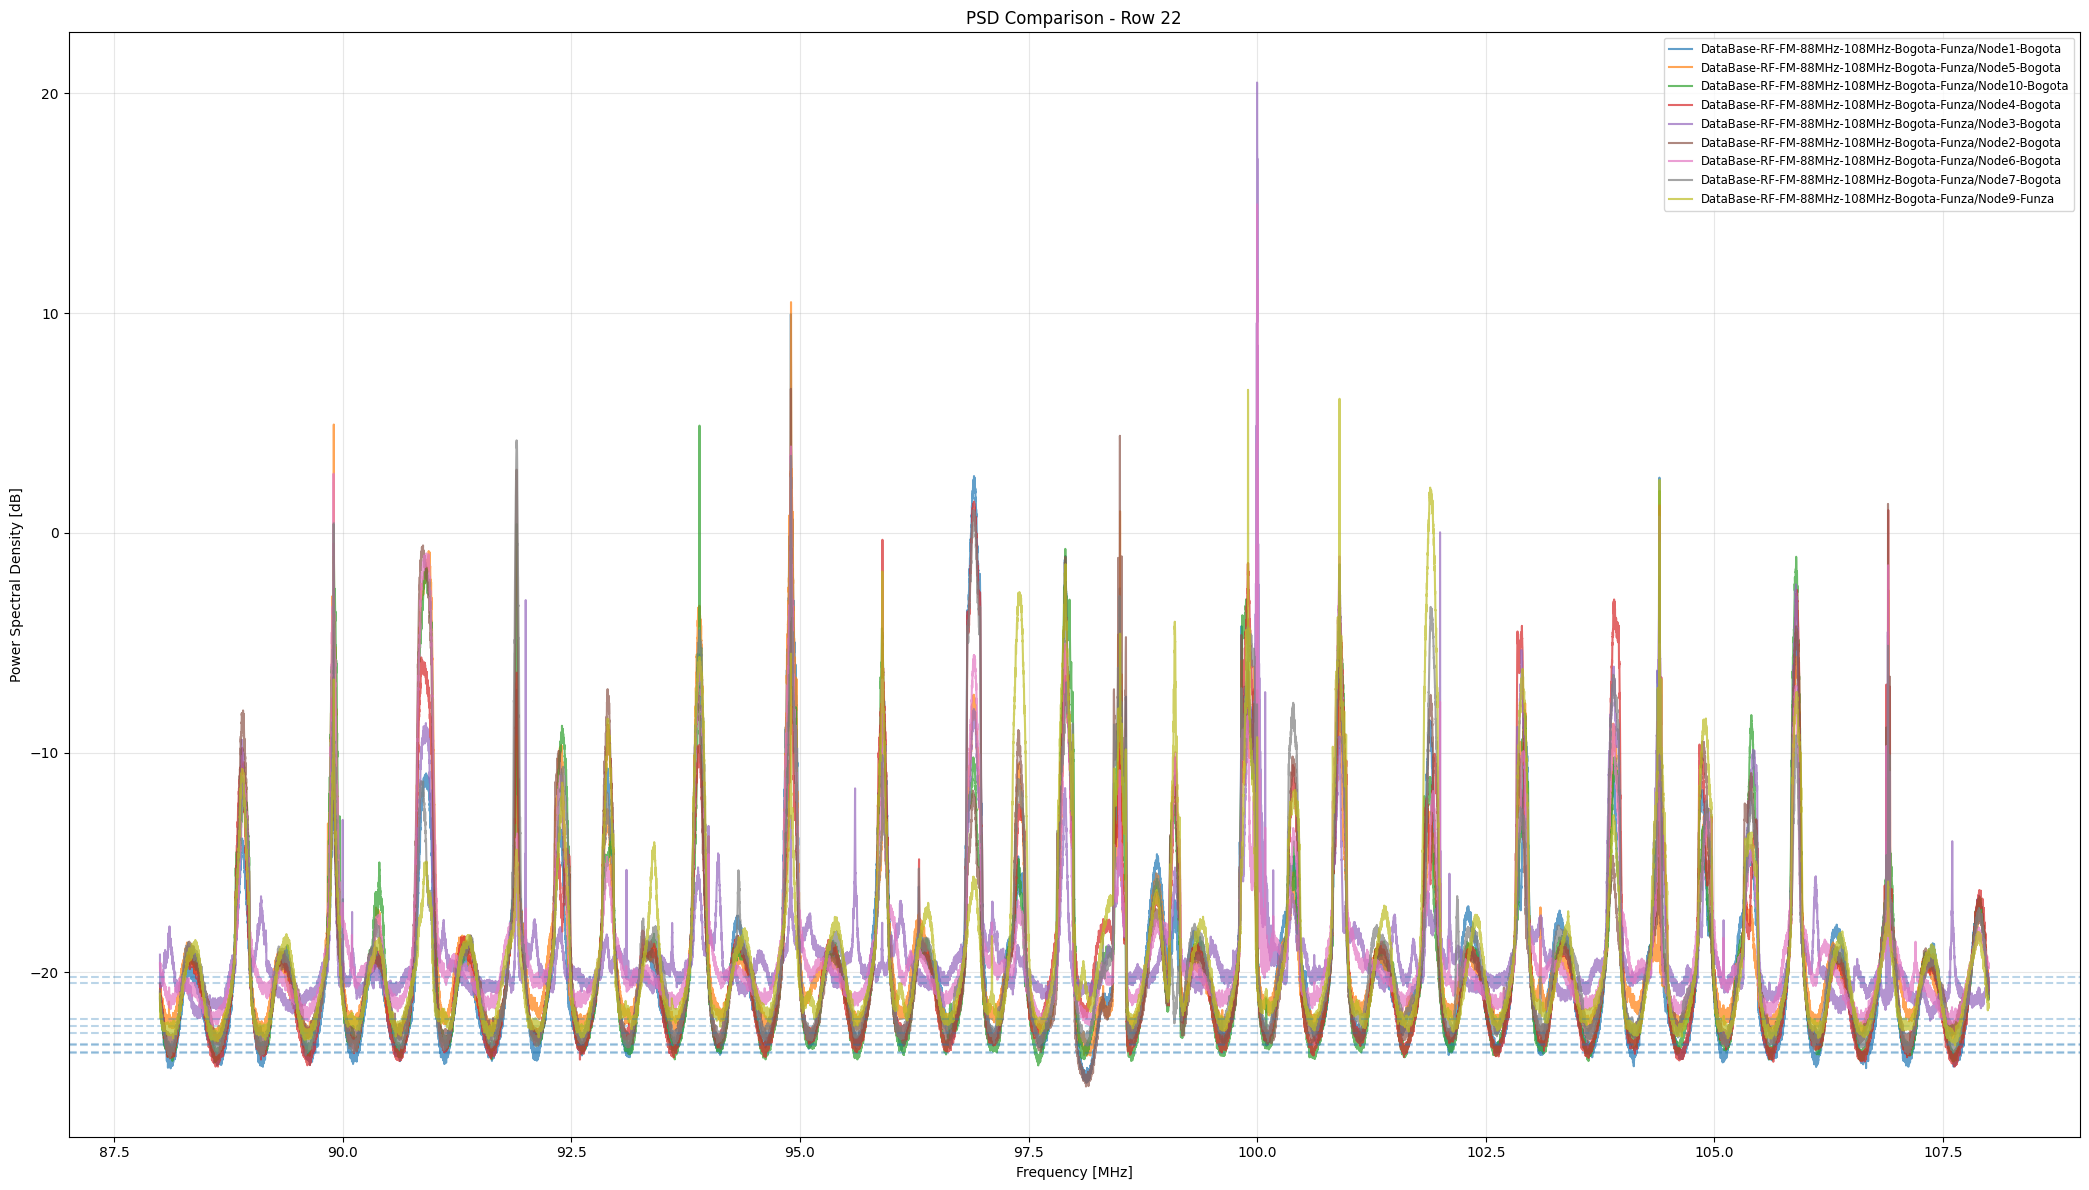


📊 Noise Floor Estimates (Row 22):
--------------------------------------------------
Node order: ['DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node1-Bogota', 'DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node10-Bogota', 'DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node2-Bogota', 'DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node3-Bogota', 'DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node4-Bogota', 'DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node5-Bogota', 'DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node6-Bogota', 'DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node7-Bogota', 'DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node9-Funza']
Noise floors [dB]: [-23.63160509 -23.65619098 -23.2947165  -20.49854384 -23.26489479
 -22.42851118 -20.21507137 -22.76916195 -22.13018244]
Statistics → Mean: -22.43 dB, Std: 1.21 dB, Min: -23.66 dB, Max: -20.22 dB

📋 Detailed Table:
Node                 Noise Floor [dB]
-----------------------------------
DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node1-Bogota          -23.63
DataBase-RF

In [40]:
import ast
import numpy as np
import matplotlib.pyplot as plt

ROW_PLOT = 22  # Change this to plot a different row [0, 105]

# Container: {node_name: {row_index: pxx_array}}
pxx_indexed = {}

# Container for noise floor estimates: {node_name: noise_floor_db}
noise_floor_estimates = {}

plt.figure(figsize=(21, 12))

for node_name, df in node_data.items():
    # Initialize nested dict for this node if needed
    if node_name not in pxx_indexed:
        pxx_indexed[node_name] = {}
    
    # Extract and parse the pxx list from the specified row
    pxx_raw = df['pxx'].iloc[ROW_PLOT]
    pxx = np.array(ast.literal_eval(pxx_raw))  # Convert string → list → numpy array
    
    # Store in indexed structure
    pxx_indexed[node_name][ROW_PLOT] = pxx
    
    # Compute corresponding frequency axis (88–108 MHz band)
    frequencies = np.linspace(88, 108, len(pxx))
    
    # Option C: Mode via histogram (best for multimodal PSDs)
    counts, bins = np.histogram(pxx, bins=50)
    noise_floor_db = bins[np.argmax(counts)]
    
    # Store estimate
    noise_floor_estimates[node_name] = noise_floor_db
    
    # Plot each node data
    plt.plot(frequencies, pxx, label=node_name, alpha=0.7)
    
    # Optional: visualize noise floor as horizontal dashed line per node
    plt.axhline(y=noise_floor_db, linestyle='--', alpha=0.3)

plt.xlabel("Frequency [MHz]")
plt.ylabel("Power Spectral Density [dB]")
plt.title(f"PSD Comparison - Row {ROW_PLOT}")
plt.legend(loc='best', fontsize='small')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 🔹 Print array of noise floor estimates
print(f"\n📊 Noise Floor Estimates (Row {ROW_PLOT}):")
print("-" * 50)

# As a simple array (ordered by node name)
node_names = sorted(noise_floor_estimates.keys())
noise_array = np.array([noise_floor_estimates[node] for node in node_names])

print("Node order:", node_names)
print("Noise floors [dB]:", noise_array)
print(f"Statistics → Mean: {np.mean(noise_array):.2f} dB, "
      f"Std: {np.std(noise_array):.2f} dB, "
      f"Min: {np.min(noise_array):.2f} dB, "
      f"Max: {np.max(noise_array):.2f} dB")

# Optional: formatted table output
print("\n📋 Detailed Table:")
print(f"{'Node':<20} {'Noise Floor [dB]':>15}")
print("-" * 35)
for node in node_names:
    print(f"{node:<20} {noise_floor_estimates[node]:>15.2f}")


📊 Noise Floor Alignment (Row 22)
------------------------------------------------------------
Global reference noise floor (mean): -22.43 dB
Per-node offsets to apply: {node: offset_dB}
  DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node1-Bogota → offset = +1.20 dB
  DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node5-Bogota → offset = -0.00 dB
  DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node10-Bogota → offset = +1.22 dB
  DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node4-Bogota → offset = +0.83 dB
  DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node3-Bogota → offset = -1.93 dB
  DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node2-Bogota → offset = +0.86 dB
  DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node6-Bogota → offset = -2.22 dB
  DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node7-Bogota → offset = +0.34 dB
  DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node9-Funza → offset = -0.30 dB


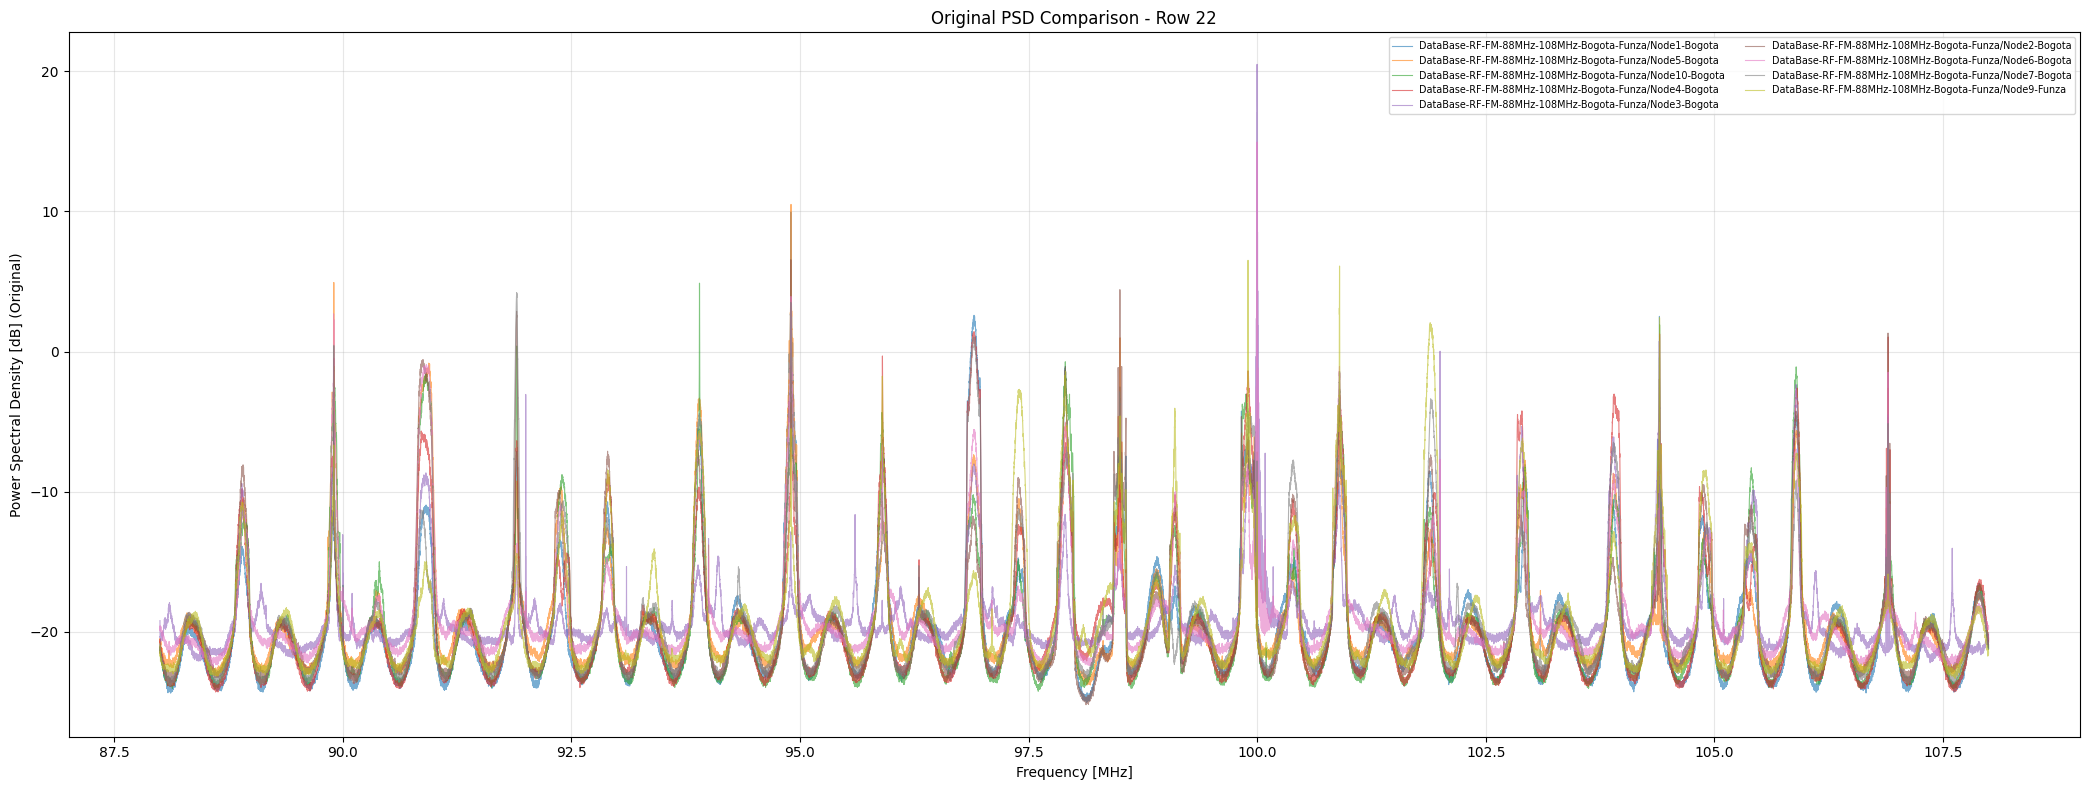

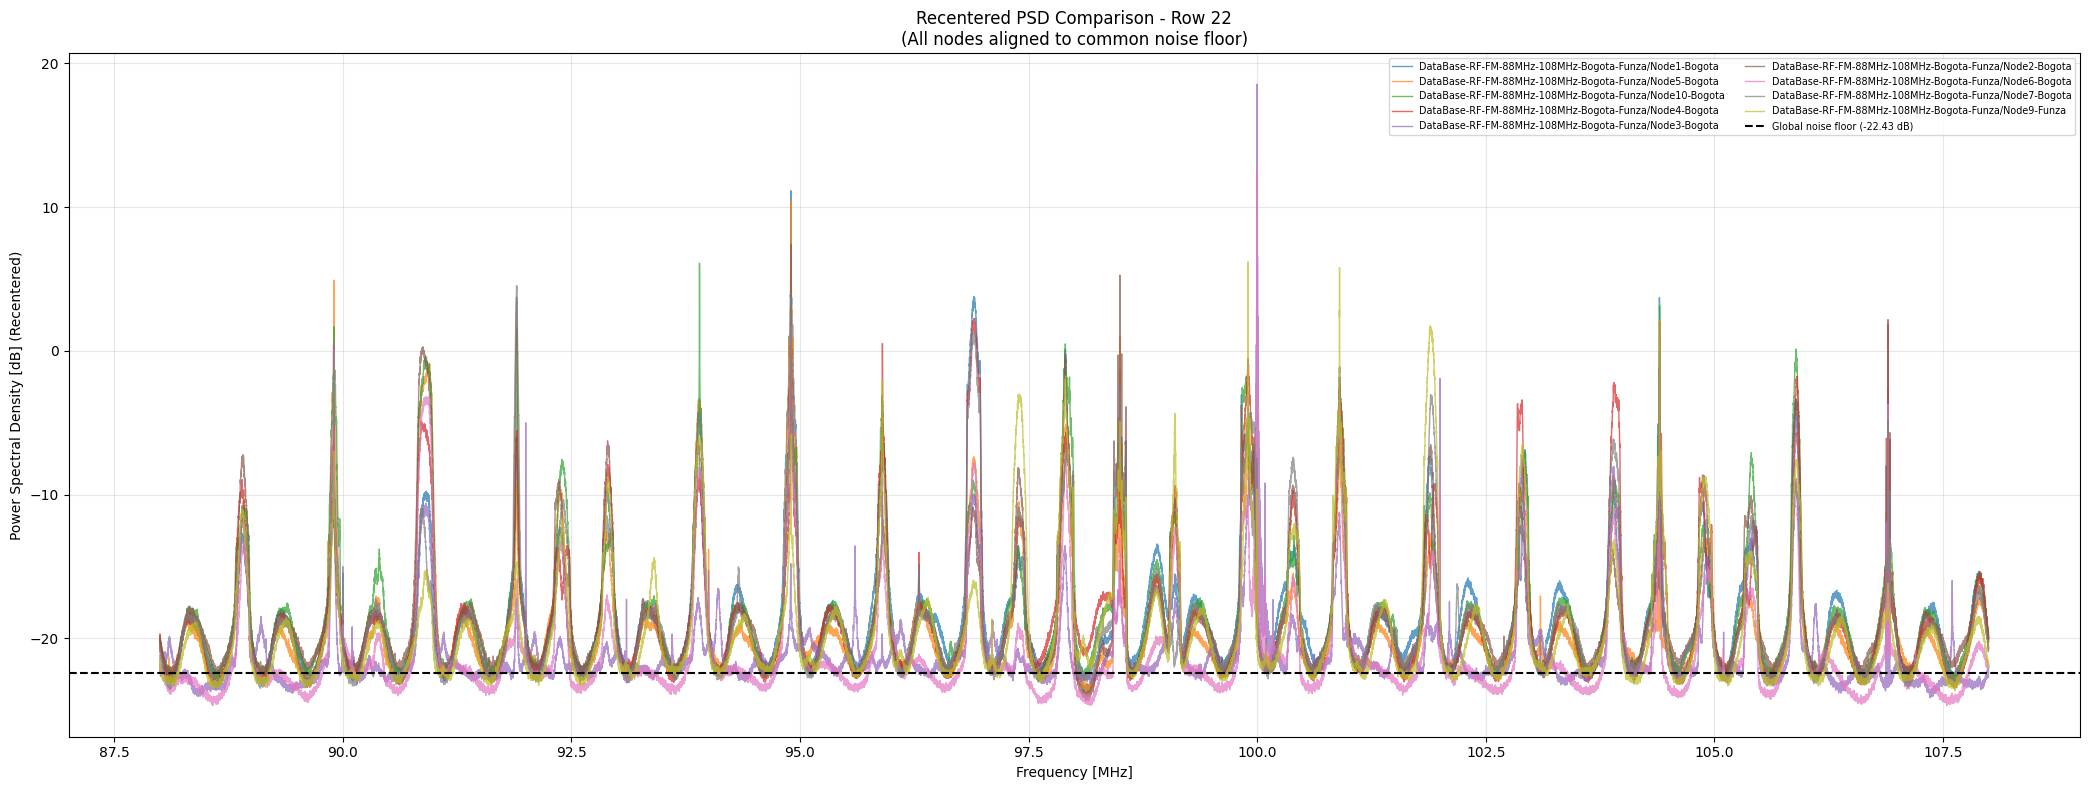


✅ Recentered data stored in 'pxx_recentered_indexed'
   Example: pxx_recentered_indexed['DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node1-Bogota'] → aligned PSD array


In [43]:
import ast
import numpy as np
import matplotlib.pyplot as plt

ROW_PLOT = 22  # Change this to plot a different row [0, 105]

# Containers
pxx_indexed = {}
noise_floor_estimates = {}

# =============================================================================
# PASS 1: Estimate noise floor for each node (using histogram mode method)
# =============================================================================
for node_name, df in node_data.items():
    if node_name not in pxx_indexed:
        pxx_indexed[node_name] = {}
    
    # Extract and parse pxx
    pxx_raw = df['pxx'].iloc[ROW_PLOT]
    pxx = np.array(ast.literal_eval(pxx_raw))
    pxx_indexed[node_name][ROW_PLOT] = pxx
    
    # Estimate noise floor: mode via histogram (robust for multimodal PSDs)
    counts, bins = np.histogram(pxx, bins=50)
    noise_floor_db = bins[np.argmax(counts)]
    noise_floor_estimates[node_name] = noise_floor_db

# =============================================================================
# Compute global reference: mean of all noise floor estimates
# =============================================================================
noise_array = np.array(list(noise_floor_estimates.values()))
global_noise_mean = np.mean(noise_array)

print(f"\n📊 Noise Floor Alignment (Row {ROW_PLOT})")
print("-" * 60)
print(f"Global reference noise floor (mean): {global_noise_mean:.2f} dB")
print(f"Per-node offsets to apply: {{node: offset_dB}}")
for node, nf in noise_floor_estimates.items():
    offset = global_noise_mean - nf
    print(f"  {node:<15} → offset = {offset:+.2f} dB")

# =============================================================================
# PASS 2: Plot ORIGINAL data (for comparison)
# =============================================================================
frequencies = np.linspace(88, 108, len(pxx_indexed[node_name][ROW_PLOT]))  # assume uniform length

plt.figure(figsize=(21, 8))
for node_name, df in node_data.items():
    pxx = pxx_indexed[node_name][ROW_PLOT]
    plt.plot(frequencies, pxx, label=node_name, alpha=0.6, linewidth=0.8)
    
plt.xlabel("Frequency [MHz]")
plt.ylabel("Power Spectral Density [dB] (Original)")
plt.title(f"Original PSD Comparison - Row {ROW_PLOT}")
plt.legend(loc='best', fontsize='x-small', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================================================
# PASS 3: Plot RECENTERED data (aligned to global noise floor)
# =============================================================================
plt.figure(figsize=(21, 8))

for node_name, df in node_data.items():
    pxx_original = pxx_indexed[node_name][ROW_PLOT]
    node_noise_floor = noise_floor_estimates[node_name]
    
    # 🔹 Recenter: shift PSD so node's noise floor matches global mean
    offset = global_noise_mean - node_noise_floor
    pxx_recentered = pxx_original + offset
    
    plt.plot(frequencies, pxx_recentered, label=node_name, alpha=0.7, linewidth=1.0)

# Visual reference: global noise floor line
plt.axhline(y=global_noise_mean, color='black', linestyle='--', linewidth=1.5, 
            label=f'Global noise floor ({global_noise_mean:.2f} dB)', zorder=5)

plt.xlabel("Frequency [MHz]")
plt.ylabel("Power Spectral Density [dB] (Recentered)")
plt.title(f"Recentered PSD Comparison - Row {ROW_PLOT}\n(All nodes aligned to common noise floor)")
plt.legend(loc='best', fontsize='x-small', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================================================
# Optional: Store recentered data for downstream use (e.g., MLP features)
# =============================================================================
pxx_recentered_indexed = {}
for node_name in node_data.keys():
    pxx_orig = pxx_indexed[node_name][ROW_PLOT]
    offset = global_noise_mean - noise_floor_estimates[node_name]
    pxx_recentered_indexed[node_name] = pxx_orig + offset

print(f"\n✅ Recentered data stored in 'pxx_recentered_indexed'")
print(f"   Example: pxx_recentered_indexed['{list(node_data.keys())[0]}'] → aligned PSD array")

Available row indices: 0 to 104

🔗 Computing pairwise correlations (Row 22)...

📊 Cumulative Correlation Scores (Row 22)
----------------------------------------------------------------------
Rank   Node                   Cumulative Score     Avg Corr
----------------------------------------------------------------------
1      DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node4-Bogota             6.8285       0.8536
2      DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node10-Bogota             6.8169       0.8521
3      DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node5-Bogota             6.7777       0.8472
4      DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node2-Bogota             6.7212       0.8401
5      DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node1-Bogota             6.7031       0.8379
6      DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node7-Bogota             6.6319       0.8290
7      DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node6-Bogota             6.5751       0.8219
8      DataBase-RF-FM-88M

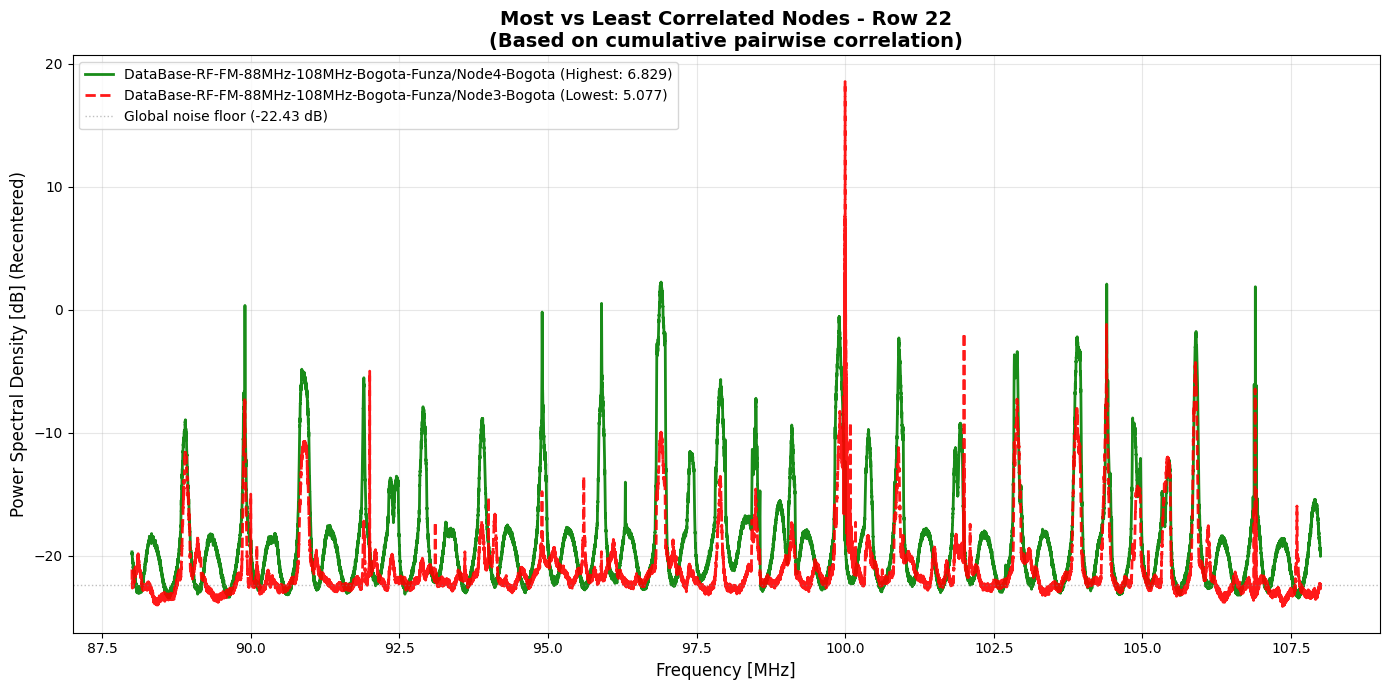

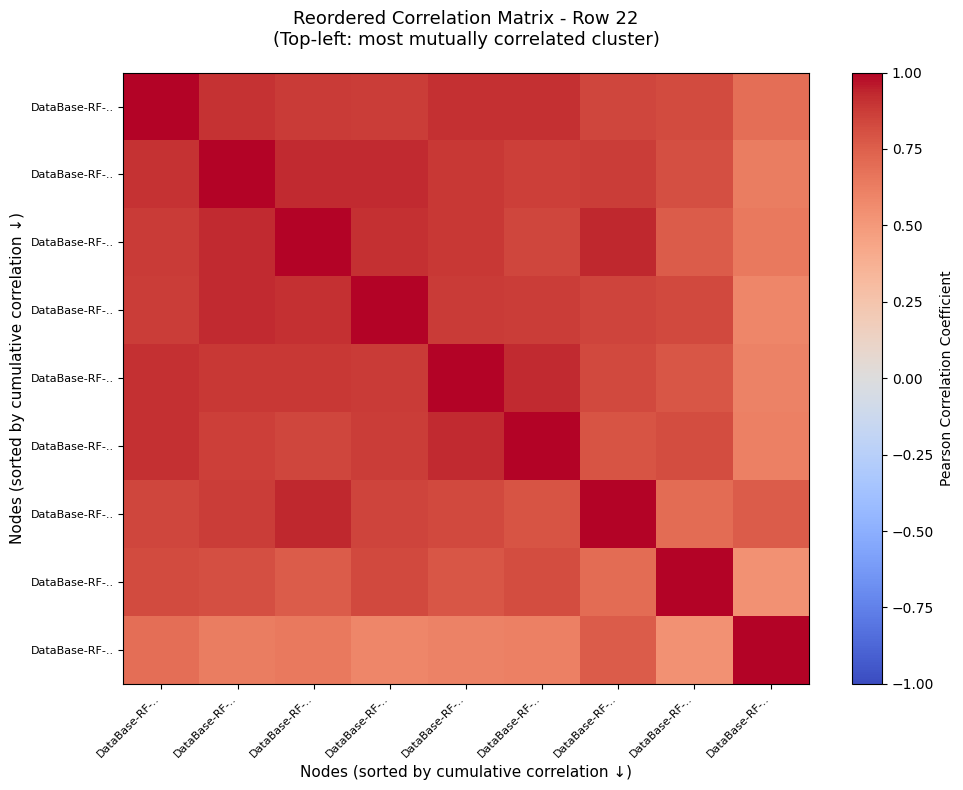


✅ Correlation analysis complete.
   Results stored in 'correlation_results' dictionary
   → Use 'correlation_results['most_representative']' for prototype selection
   → Use 'correlation_results['most_distinctive']' for anomaly detection


In [46]:
import ast
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Verify actual range first:
print(f"Available row indices: {list(node_data.values())[0].index.min()} to {list(node_data.values())[0].index.max()}")

data_record = 22  # Change this to plot a different row [1, 103]

# Containers
pxx_indexed = {}
noise_floor_estimates = {}

# =============================================================================
# PASS 1: Estimate noise floor and store recentered PSDs
# =============================================================================
for node_name, df in node_data.items():
    if node_name not in pxx_indexed:
        pxx_indexed[node_name] = {}
    
    pxx_raw = df['pxx'].iloc[data_record]
    pxx = np.array(ast.literal_eval(pxx_raw))
    pxx_indexed[node_name][data_record] = pxx
    
    # Estimate noise floor: mode via histogram
    counts, bins = np.histogram(pxx, bins=50)
    noise_floor_db = bins[np.argmax(counts)]
    noise_floor_estimates[node_name] = noise_floor_db

# Compute global reference noise floor
noise_array = np.array(list(noise_floor_estimates.values()))
global_noise_mean = np.mean(noise_array)

# Build recentered + Z-normalized PSD dictionary for correlation analysis
pxx_processed = {}
for node_name in node_data.keys():
    pxx_orig = pxx_indexed[node_name][data_record]
    offset = global_noise_mean - noise_floor_estimates[node_name]
    pxx_recentered = pxx_orig + offset
    
    # 🔹 Z-normalize: zero mean, unit variance (essential for fair correlation)
    pxx_norm = (pxx_recentered - np.mean(pxx_recentered)) / (np.std(pxx_recentered) + 1e-8)
    pxx_processed[node_name] = pxx_norm

# =============================================================================
# PASS 2: Compute pairwise Pearson correlation matrix
# =============================================================================
node_names = sorted(node_data.keys())
n_nodes = len(node_names)
corr_matrix = np.zeros((n_nodes, n_nodes))

print(f"\n🔗 Computing pairwise correlations (Row {data_record})...")
for i, node_i in enumerate(node_names):
    for j, node_j in enumerate(node_names):
        if i == j:
            corr_matrix[i, j] = 1.0
        elif j > i:
            # Pearson correlation between two PSD vectors
            corr_val, _ = pearsonr(pxx_processed[node_i], pxx_processed[node_j])
            corr_matrix[i, j] = corr_val
            corr_matrix[j, i] = corr_val  # Symmetric matrix

# =============================================================================
# PASS 3: Cumulative correlation score per node (row sums)
# =============================================================================
# Sum of correlations with all other nodes (excluding self-correlation = 1)
cumulative_scores = np.sum(corr_matrix, axis=1) - 1.0  # subtract diagonal

# Create ranking: nodes sorted by cumulative score (descending)
ranking_idx = np.argsort(cumulative_scores)[::-1]  # descending order
ranked_nodes = [node_names[i] for i in ranking_idx]
ranked_scores = cumulative_scores[ranking_idx]
ranked_corr_matrix = corr_matrix[np.ix_(ranking_idx, ranking_idx)]

print(f"\n📊 Cumulative Correlation Scores (Row {data_record})")
print("-" * 70)
print(f"{'Rank':<6} {'Node':<20} {'Cumulative Score':>18} {'Avg Corr':>12}")
print("-" * 70)
for rank, (node, score) in enumerate(zip(ranked_nodes, ranked_scores), 1):
    avg_corr = (score) / (n_nodes - 1)  # average correlation with others
    print(f"{rank:<6} {node:<20} {score:>18.4f} {avg_corr:>12.4f}")

# =============================================================================
# PASS 4: Identify highest and lowest cumulative correlation nodes
# =============================================================================
idx_highest = ranking_idx[0]   # Most correlated with the group
idx_lowest = ranking_idx[-1]   # Least correlated (most unique)

node_highest = node_names[idx_highest]
node_lowest = node_names[idx_lowest]

print(f"\n🎯 Key Nodes:")
print(f"   Highest cumulative correlation: {node_highest} ({ranked_scores[0]:.4f})")
print(f"   Lowest  cumulative correlation: {node_lowest}  ({ranked_scores[-1]:.4f})")
print(f"   → These nodes represent: 'most typical' vs 'most distinctive' spectral profiles")

# =============================================================================
# PASS 5: Plot TOP and BOTTOM nodes (recentered PSDs)
# =============================================================================
frequencies = np.linspace(88, 108, len(pxx_processed[node_names[0]]))

plt.figure(figsize=(14, 7))

# Plot highest cumulative correlation node
pxx_high = pxx_indexed[node_highest][data_record]
offset_high = global_noise_mean - noise_floor_estimates[node_highest]
pxx_high_rec = pxx_high + offset_high
plt.plot(frequencies, pxx_high_rec, label=f'{node_highest} (Highest: {ranked_scores[0]:.3f})', 
         color='green', linewidth=2, alpha=0.9)

# Plot lowest cumulative correlation node
pxx_low = pxx_indexed[node_lowest][data_record]
offset_low = global_noise_mean - noise_floor_estimates[node_lowest]
pxx_low_rec = pxx_low + offset_low
plt.plot(frequencies, pxx_low_rec, label=f'{node_lowest} (Lowest: {ranked_scores[-1]:.3f})', 
         color='red', linewidth=2, alpha=0.9, linestyle='--')

# Reference line
plt.axhline(y=global_noise_mean, color='gray', linestyle=':', linewidth=1, alpha=0.5,
            label=f'Global noise floor ({global_noise_mean:.2f} dB)')

plt.xlabel("Frequency [MHz]", fontsize=12)
plt.ylabel("Power Spectral Density [dB] (Recentered)", fontsize=12)
plt.title(f"Most vs Least Correlated Nodes - Row {data_record}\n(Based on cumulative pairwise correlation)", 
          fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

# =============================================================================
# PASS 6: Visualize reordered correlation matrix (optional but insightful)
# =============================================================================
plt.figure(figsize=(10, 8))
im = plt.imshow(ranked_corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')

# Annotate with node names (rotated for readability)
plt.xticks(np.arange(n_nodes), [n[:12]+'..' if len(n)>14 else n for n in ranked_nodes], 
           rotation=45, ha='right', fontsize=8)
plt.yticks(np.arange(n_nodes), [n[:12]+'..' if len(n)>14 else n for n in ranked_nodes], 
           fontsize=8)

plt.xlabel("Nodes (sorted by cumulative correlation ↓)", fontsize=11)
plt.ylabel("Nodes (sorted by cumulative correlation ↓)", fontsize=11)
plt.title(f"Reordered Correlation Matrix - Row {data_record}\n(Top-left: most mutually correlated cluster)", 
          fontsize=13, pad=20)
plt.colorbar(im, label='Pearson Correlation Coefficient')
plt.grid(False)
plt.tight_layout()
plt.show()

# =============================================================================
# Output: Save results for downstream use (e.g., MLP feature selection)
# =============================================================================
correlation_results = {
    'row_plot': data_record,
    'node_names': node_names,
    'corr_matrix': corr_matrix,
    'cumulative_scores': dict(zip(node_names, cumulative_scores)),
    'ranking': ranked_nodes,
    'ranked_scores': dict(zip(ranked_nodes, ranked_scores)),
    'most_representative': node_highest,
    'most_distinctive': node_lowest,
    'global_noise_mean': global_noise_mean
}

print(f"\n✅ Correlation analysis complete.")
print(f"   Results stored in 'correlation_results' dictionary")
print(f"   → Use 'correlation_results['most_representative']' for prototype selection")
print(f"   → Use 'correlation_results['most_distinctive']' for anomaly detection")

Available row indices: 0 to 104
